In [120]:
import torch
import numpy as np
import torch.nn as nn
from torch.utils.data import Dataset, DataLoader
import matplotlib.pyplot as  plt
import os

class MIBCI2aDataset(torch.utils.data.Dataset):
    def _getFeatures(self, filePath,mode):
        # implement the getFeatures method
        """
        read all the preprocessed data from the file path, read it using np.load,
        and concatenate them into a single numpy array
        """
        if(mode == 'train'):
            filepath = os.path.join(filePath, "s1T.npy")
            features = np.load(filepath)
            for i in range (2,10):
                filename = f'S{i}T.npy'
                filepath = os.path.join(filePath, filename)
                if os.path.exists(filepath):
                    temp = np.load(filepath)
                    features = np.concatenate((features,temp),axis=0)
        if(mode == 'test'):
            filepath = os.path.join(filePath, "s1E.npy")
            features = np.load(filepath)
            for i in range (2,10):
                filename = f'S{i}E.npy'
                filepath = os.path.join(filePath, filename)
                if os.path.exists(filepath):
                    temp = np.load(filepath)
                    features = np.concatenate((features,temp),axis=0)
        print(features.shape)
        return features

    def _getLabels(self, filePath,mode):
        # implement the getLabels method
        """
        read all the preprocessed labels from the file path, read it using np.load,
        and concatenate them into a single numpy array
        """
        if(mode=='train'):
            filepath = os.path.join(filePath, "s1T.npy")
            labels = np.load(filepath)
            for i in range (2,10):
                filename = f'S{i}T.npy'
                filepath = os.path.join(filePath, filename)
                if os.path.exists(filepath):
                    temp = np.load(filepath)
                    labels= np.concatenate((labels,temp),axis=0)
        if(mode == 'test'):
            filepath = os.path.join(filePath, "s1E.npy")
            labels = np.load(filepath)
            for i in range (2,10):
                filename = f'S{i}E.npy'
                filepath = os.path.join(filePath, filename)
                if os.path.exists(filepath):
                    temp = np.load(filepath)
                    labels = np.concatenate((labels,temp),axis=0)
        print(labels.shape)   
        return labels

        

    def __init__(self, mode):
        # remember to change the file path according to different experiments
        assert mode in ['train', 'test', 'finetune']
        if mode == 'train':
            # subject dependent: ./dataset/SD_train/features/ and ./dataset/SD_train/labels/
            # leave-one-subject-out: ./dataset/LOSO_train/features/ and ./dataset/LOSO_train/labels/
            self.features = self._getFeatures(filePath='./dataset/SD_train/features/',mode = mode)
            self.labels = self._getLabels(filePath='./dataset/SD_train/labels/',mode = mode)
        if mode == 'finetune':
            # finetune: ./dataset/FT/features/ and ./dataset/FT/labels/
            self.features = self._getFeatures(filePath='./dataset/FT/features/',mode = mode)
            self.labels = self._getLabels(filePath='./dataset/FT/labels/',mode = mode)
        if mode == 'test':
            # subject dependent: ./dataset/SD_test/features/ and ./dataset/SD_test/labels/
            # leave-one-subject-out and finetune: ./dataset/LOSO_test/features/ and ./dataset/LOSO_test/labels/
            self.features = self._getFeatures(filePath='./dataset/SD_test/features/',mode = mode)
            self.labels = self._getLabels(filePath='./dataset/SD_test/labels/',mode = mode)

    def __len__(self):
        return len(self.features)
        

    def __getitem__(self, idx):
        return self.features[idx],self.labels[idx]

In [115]:
#for LOSO
class MIBCI2aDataset(torch.utils.data.Dataset):
    def _getFeatures(self, filePath,mode):
        # implement the getFeatures method
        """
        read all the preprocessed data from the file path, read it using np.load,
        and concatenate them into a single numpy array
        """
        if(mode == 'train'):
            filepath = os.path.join(filePath, "s1T.npy")
            features = np.load(filepath)
            filepath = os.path.join(filePath, "s1E.npy")
            temp = np.load(filepath)
            features = np.concatenate((features,temp),axis=0)
            for i in range (1,10):
                filename = f'S{i}T.npy'
                filepath = os.path.join(filePath, filename)
                if os.path.exists(filepath):
                    temp = np.load(filepath)
                    features = np.concatenate((features,temp),axis=0)
                filename = f'S{i}E.npy'
                filepath = os.path.join(filePath, filename)
                if os.path.exists(filepath):
                    temp = np.load(filepath)
                    features = np.concatenate((features,temp),axis=0)
        if(mode == 'test'):
            filepath = os.path.join(filePath, "s9E.npy")
            features = np.load(filepath)
        print(features.shape)
        return features

    def _getLabels(self, filePath,mode):
        # implement the getLabels method
        """
        read all the preprocessed labels from the file path, read it using np.load,
        and concatenate them into a single numpy array
        """
        if(mode=='train'):
            filepath = os.path.join(filePath, "s1T.npy")
            labels = np.load(filepath)
            filepath = os.path.join(filePath, "s1E.npy")
            temp = np.load(filepath)
            labels = np.concatenate((labels,temp),axis=0)
            for i in range (1,10):
                filename = f'S{i}T.npy'
                filepath = os.path.join(filePath, filename)
                if os.path.exists(filepath):
                    temp = np.load(filepath)
                    labels= np.concatenate((labels,temp),axis=0)
                filename = f'S{i}E.npy'
                filepath = os.path.join(filePath, filename)
                if os.path.exists(filepath):
                    temp = np.load(filepath)
                    labels = np.concatenate((labels,temp),axis=0)
        if(mode == 'test'):
            filepath = os.path.join(filePath, "s9E.npy")
            labels = np.load(filepath)
        print(labels.shape)   
        return labels

        

    def __init__(self, mode):
        # remember to change the file path according to different experiments
        assert mode in ['train', 'test', 'finetune']
        if mode == 'train':
            # subject dependent: ./dataset/SD_train/features/ and ./dataset/SD_train/labels/
            # leave-one-subject-out: ./dataset/LOSO_train/features/ and ./dataset/LOSO_train/labels/
            self.features = self._getFeatures(filePath='./dataset/LOSO_train/features/',mode = mode)
            self.labels = self._getLabels(filePath='./dataset/LOSO_train/labels/',mode = mode)
        if mode == 'finetune':
            # finetune: ./dataset/FT/features/ and ./dataset/FT/labels/
            self.features = self._getFeatures(filePath='./dataset/FT/features/',mode = mode)
            self.labels = self._getLabels(filePath='./dataset/FT/labels/',mode = mode)
        if mode == 'test':
            # subject dependent: ./dataset/SD_test/features/ and ./dataset/SD_test/labels/
            # leave-one-subject-out and finetune: ./dataset/LOSO_test/features/ and ./dataset/LOSO_test/labels/
            self.features = self._getFeatures(filePath='./dataset/LOSO_test/features/',mode = mode)
            self.labels = self._getLabels(filePath='./dataset/LOSO_test/labels/',mode = mode)

    def __len__(self):
        return len(self.features)
        

    def __getitem__(self, idx):
        return self.features[idx],self.labels[idx]

In [106]:
#大腦電極的運作
#(進行288次,電極通道數量,時間點) 9個人的資料
filePath = './dataset/LOSO_train/features/'
filepath = os.path.join(filePath, "s1T.npy")
features = np.load(filepath)


filePath = './dataset/LOSO_train/labels/'
filepath = os.path.join(filePath, "s1E.npy")
labels = np.load(filepath)



print(features.shape)
print(labels.shape)
print(len(features))


(288, 22, 438)
(288,)
288


In [147]:
class SquareLayer(nn.Module):
    def __init__(self):
        super().__init__()

    def forward(self, x):
        return torch.pow(x, 2)

# 定義 SCCNet 類別
class SCCNet(nn.Module):
    def __init__(self, numClasses=4, timeSample=438, Nu=22, C=22, Nc=20, Nt=1, dropoutRate=0.5):
        super(SCCNet, self).__init__()
        
        # 第一卷積層
        self.conv1 = nn.Conv2d(1, Nu, (C, Nt), padding=(0, 0))
        self.bn1 = nn.BatchNorm2d(Nu)
        
        
        # 第二卷積層
        self.conv2 = nn.Conv2d(1, Nc, (Nu, 12), padding=(0, 0))
        self.bn2 = nn.BatchNorm2d(Nc)
        
        # 平方層
        self.square = SquareLayer()
        
        # dropout
        self.dropout = nn.Dropout(dropoutRate)
        
        # pooling (use average pooling)
        self.pool = nn.AvgPool2d((1, 62), stride=(1, 12)) 
        
        # soft max
        self.fc = nn.Linear(620, numClasses) #620
        
     
    def forward(self, x):
        x = x.unsqueeze(1)  # 添加一個維度，從 (batch, Nc, T) 變為 (batch, 1, Nc, T)
        #print("After unsqueeze:", x.shape)
        #print("Input shape:", x.shape)
       

        x = self.conv1(x)
        #print("After conv1:", x.shape)
        
        
        
        x = self.bn1(x)
        #print("After bn1:", x.shape)
        x = self.square(x)
        #print("After square1:", x.shape)
       
        x = x.permute(0,2, 1, 3)
       # print("After permute:", x.shape)
        x = self.conv2(x)
        #print("After conv2:", x.shape)
        x = self.bn2(x)
        #print("After bn2:", x.shape)
        #x = self.square(x)
        
        #print("After square2:", x.shape)
        
        x = self.dropout(x)
        #print("After dropout:", x.shape)
        x = self.pool(x)
       #print("After pool:", x.shape)
        
        
        
        x = x.flatten(1)  # 攤平，用於全連接層
        
        #print("After flatten:", x.shape)
        x = self.fc(x)
        #print("After fc:", x.shape)
       
        return x

In [138]:
train_set = MIBCI2aDataset(mode='train')
test_set = MIBCI2aDataset(mode='test')
dataset_length = len(train_set)


dataloader = DataLoader(train_set,batch_size=32,shuffle =True)

testloader = DataLoader(test_set,batch_size=32)


(2304, 22, 438)
(2304,)
(2304, 22, 438)
(2304,)


[ Train | 001/1000 ] loss = 1.35865, acc = 0.31901
[ Train | 002/1000 ] loss = 1.27500, acc = 0.40755
[ Train | 003/1000 ] loss = 1.21807, acc = 0.44661
[ Train | 004/1000 ] loss = 1.19872, acc = 0.45964
[ Train | 005/1000 ] loss = 1.16707, acc = 0.48828
[ Train | 006/1000 ] loss = 1.14835, acc = 0.49783
[ Train | 007/1000 ] loss = 1.13189, acc = 0.49306
[ Train | 008/1000 ] loss = 1.11662, acc = 0.51866
[ Train | 009/1000 ] loss = 1.11781, acc = 0.50825
[ Train | 010/1000 ] loss = 1.10455, acc = 0.51562
[ Train | 011/1000 ] loss = 1.08630, acc = 0.53168
[ Train | 012/1000 ] loss = 1.07275, acc = 0.53776
[ Train | 013/1000 ] loss = 1.05907, acc = 0.53472
[ Train | 014/1000 ] loss = 1.06996, acc = 0.53819
[ Train | 015/1000 ] loss = 1.05175, acc = 0.53906
[ Train | 016/1000 ] loss = 1.03781, acc = 0.55122
[ Train | 017/1000 ] loss = 1.02691, acc = 0.55469
[ Train | 018/1000 ] loss = 1.03210, acc = 0.55729
[ Train | 019/1000 ] loss = 1.02291, acc = 0.56510
[ Train | 020/1000 ] loss = 1.0

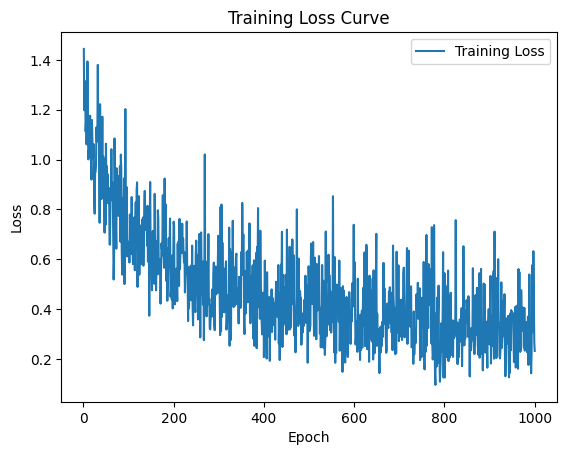

In [148]:
# "cuda" only when GPUs are available.
device = "cuda" if torch.cuda.is_available() else "cpu"

# Initialize a model, and put it on the device specified.
model = SCCNet().to(device)
model.device = device

#loss function
criterion = nn.CrossEntropyLoss()

# L2 regulation 
optimizer = torch.optim.Adam(model.parameters(), lr=0.001, weight_decay=1e-4)

# The number of training epochs.
n_epochs =1000

softmax = nn.Softmax(dim=-1)

train_losses = []

for epoch in range(n_epochs):
    # These are used to record information in training.
    train_loss = []
    train_accs = []
    
    
    ###################training#############################
    model.train()
    for batch_idx, (features, labels) in enumerate(dataloader):
        features, labels = features.to(device), labels.to(device)
        
        

        # Forward the data. (Make sure data and model are on the same device.)
        
        logits = model(features.to(torch.float32))

        # Obtain the probability distributions by applying softmax on logits.
        probs = softmax(logits)
        
        # Calculate the cross-entropy loss.
        # We don't need to apply softmax before computing cross-entropy as it is done automatically.
        loss = criterion(logits, labels.to(torch.int64))
    
        
        # Gradients stored in the parameters in the previous step should be cleared out first.
        optimizer.zero_grad()

        # Compute the gradients for parameters.
        loss.backward()

        # Update the parameters with computed gradients.
        optimizer.step()

        # Compute the accuracy for current batch.
        acc = (logits.argmax(dim=-1) == labels).float().mean()

        # Record the loss and accuracy.
        train_loss.append(loss.item())
        train_accs.append(acc)
        
        
    # The average loss and accuracy of the training set is the average of the recorded values.
    train_loss = sum(train_loss) / len(train_loss)
    train_acc = sum(train_accs) / len(train_accs)
    
    train_losses.append(loss.item())
    
    # Print the information.
    print(f"[ Train | {epoch + 1:03d}/{n_epochs:03d} ] loss = {train_loss:.5f}, acc = {train_acc:.5f}")
    
plt.figure()
plt.plot(range(1, n_epochs + 1), train_losses, label='Training Loss')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.title('Training Loss Curve')
plt.legend()   


In [150]:
model.eval()
test_loss = 0
correct = 0
predictions = []
true_labels = []

with torch.no_grad():
    for features, labels in testloader:
        features, labels = features.to(device), labels.to(device)
        
        # Forward pass
        logits = model(features.to(torch.float32))
        preds =softmax(logits)
        # Calculate loss
        loss = criterion(logits, labels.to(torch.int64))
        test_loss += loss.item()  # Accumulate the total test loss
        
        # Get predicted labels
        preds = logits.argmax(dim=1)
        predictions.extend(preds.cpu().numpy())  # Store predicted labels
        true_labels.extend(labels.cpu().numpy())  # Store true labels for comparison
        
        # Calculate accuracy
        correct += (preds == labels).sum().item()

# Average test loss
avg_test_loss = test_loss / len(testloader)

# Accuracy calculation
accuracy = correct / len(testloader.dataset)

print(f"Average Test Loss: {avg_test_loss:.4f}")
print(f"Accuracy: {accuracy * 100:.2f}%")




#test_loss /= len(testloader.dataset)
    
#print('\nTest set: Average loss: {:.4f}, Accuracy: {}/{} ({:.0f}%)\n'.format(
        #test_loss, correct, len(testloader.dataset),
        #100. * correct / len(testloader.dataset)))

Average Test Loss: 2.9234
Accuracy: 44.44%
